In [1]:
import os

In [2]:
print (os.getcwd())

f:\guvi


In [1]:
%pip install gitpython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import git
repo_url="https://github.com/PhonePe/pulse.git"
clone_dir="phonepe_pulse_data"
if not os.path.exists(clone_dir):

    git.Repo.clone_from(repo_url,clone_dir)
else:

    print("already cloned")

already cloned


In [3]:
import pandas as pd
import os
path="phonepe_pulse_data/data/aggregated/transaction/country/india/state/"
agg_state_list=os.listdir(path)
agg_state_list

['andaman-&-nicobar-islands',
 'andhra-pradesh',
 'arunachal-pradesh',
 'assam',
 'bihar',
 'chandigarh',
 'chhattisgarh',
 'dadra-&-nagar-haveli-&-daman-&-diu',
 'delhi',
 'goa',
 'gujarat',
 'haryana',
 'himachal-pradesh',
 'jammu-&-kashmir',
 'jharkhand',
 'karnataka',
 'kerala',
 'ladakh',
 'lakshadweep',
 'madhya-pradesh',
 'maharashtra',
 'manipur',
 'meghalaya',
 'mizoram',
 'nagaland',
 'odisha',
 'puducherry',
 'punjab',
 'rajasthan',
 'sikkim',
 'tamil-nadu',
 'telangana',
 'tripura',
 'uttar-pradesh',
 'uttarakhand',
 'west-bengal']

In [7]:
state_mapping={
    'andaman-&-nicobar-islands':'Andaman & Nicobar',
 'andhra-pradesh':'Andhra Pradesh',
 'arunachal-pradesh':'Arunachal Pradesh',
 'assam':'Assam',
 'bihar':'Bihar',
 'chandigarh':'Chandigarh',
 'chhattisgarh':'Chhattisgarh',
 'dadra-&-nagar-haveli-&-daman-&-diu':'Dadra and Nagar Haveli and Daman and Diu',
 'delhi':'Delhi',
 'goa':'Goa',
 'gujarat':'Gujarat',
 'haryana':'Haryana',
 'himachal-pradesh':'Himachal Pradesh',
 'jammu-&-kashmir':'Jammu & Kashmir',
 'jharkhand':'Jharkhand',
 'karnataka':'Karnataka',
 'kerala':'Kerala',
 'ladakh':'Ladakh',
 'lakshadweep':'Lakshadweep',
 'madhya-pradesh':'Madhya Pradesh',
 'maharashtra':'Maharashtra',
 'manipur':'Manipur',
 'meghalaya':'Meghalaya',
 'mizoram':'Mizoram',
 'nagaland':'Nagaland',
 'odisha':'Odisha',
 'puducherry':'Puducherry',
 'punjab':'Punjab',
 'rajasthan':'Rajasthan',
 'sikkim':'Sikkim',
 'tamil-nadu':'Tamil Nadu',
 'telangana': 'Telangana',
 'tripura':'Tripura',
 'uttar-pradesh':'Uttar Pradesh',
 'uttarakhand':'Uttarakhand',
 'west-bengal':'West Bengal'
}

In [8]:
import json

In [9]:

clm={"state":[],"year":[],"quarter":[],"transaction_type":[],"transaction_count":[],"transaction_amount":[]}
for i in agg_state_list:
    p_i=path+i+"/"
    agg_year=os.listdir(p_i)
    #print(agg_year_list)
    #print(f"{i}: {len(agg_year_list)}")
    for j in agg_year:
        p_j=p_i+j+"/"
        agg_year_list=os.listdir(p_j)
        for k in agg_year_list:
            p_k=p_j+k
            data=open(p_k,'r')
            D=json.load(data)
            for z in D["data"]["transactionData"]:
                name=z["name"]
                count=z["paymentInstruments"][0]["count"]
                amount=z["paymentInstruments"][0]["amount"]
                clm["transaction_amount"].append(amount)
                clm["transaction_count"].append(count)
                clm["transaction_type"].append(name)
                clm["state"].append(i)
                clm["year"].append(j)
                clm["quarter"].append(int(k.strip('.json')))
agg_transaction=pd.DataFrame(clm)






         
        


     


     

In [ ]:
agg_transaction


,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,Andaman & Nicobar,2018,1,Recharge & bill payments,4200,1.845307e+06
1,Andaman & Nicobar,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,Andaman & Nicobar,2018,1,Merchant payments,298,4.525072e+05
3,Andaman & Nicobar,2018,1,Financial Services,33,1.060142e+04
4,Andaman & Nicobar,2018,1,Others,256,1.846899e+05
...,...,...,...,...,...,...
5029,West Bengal,2024,4,Merchant payments,655100809,3.892862e+11
5030,West Bengal,2024,4,Peer-to-peer payments,493217788,1.361927e+12
5031,West Bengal,2024,4,Recharge & bill payments,76043195,5.753406e+10
5032,West Bengal,2024,4,Financial Services,2352084,8.472965e+08


In [13]:
agg_transaction["state"]=agg_transaction["state"].replace(state_mapping)
agg_transaction["state"]

0       Andaman & Nicobar
1       Andaman & Nicobar
2       Andaman & Nicobar
3       Andaman & Nicobar
4       Andaman & Nicobar
              ...        
5029          West Bengal
5030          West Bengal
5031          West Bengal
5032          West Bengal
5033          West Bengal
Name: state, Length: 5034, dtype: object

In [11]:
path="phonepe_pulse_data/data/aggregated/user/country/india/state/" 
agg_user_state=os.listdir(path)

#agg_user_state



In [12]:

clm1={"state":[],"year":[],"quarter":[],"brand":[],"brand_count":[],"percentage":[]}
for i in agg_user_state:
    p_i=path+i+"/"
    agg_user_year=os.listdir(p_i)
    #print(agg_year_list)
    #print(f"{i}: {len(agg_year_list)}")
    for j in agg_user_year:
        p_j=p_i+j+"/"
        agg_user_year_list=os.listdir(p_j)
        for k in agg_user_year_list:
            p_k=p_j+k
            #print(p_k)
            data=open(p_k,'r')
            D1=json.load(data)
            try :
                for x in D1["data"]["usersByDevice"]:
                    brand_name=x["brand"]
                    brand_count=x["count"]
                    brand_percentage=x["percentage"]
                    clm1["brand"].append(brand_name)
                    clm1["brand_count"].append(brand_count)
                    clm1["percentage"].append(brand_percentage)
                    clm1["state"].append(i)
                    clm1["year"].append(j)
                    clm1["quarter"].append(int(k.strip('.json')))
            except:
                pass

agg_user=pd.DataFrame(clm1)


In [13]:
agg_user[agg_user["state"]=="andaman-&-nicobar-islands"]["year"].unique()

array(['2018', '2019', '2020', '2021', '2022'], dtype=object)

In [14]:
#agg_user
agg_user["state"]=agg_user["state"].replace(state_mapping)
agg_user["state"]

0       Andaman & Nicobar
1       Andaman & Nicobar
2       Andaman & Nicobar
3       Andaman & Nicobar
4       Andaman & Nicobar
              ...        
6727          West Bengal
6728          West Bengal
6729          West Bengal
6730          West Bengal
6731          West Bengal
Name: state, Length: 6732, dtype: object

In [15]:
agg_user

,state,year,quarter,brand,brand_count,percentage
0,Andaman & Nicobar,2018,1,Xiaomi,1665,0.247033
1,Andaman & Nicobar,2018,1,Samsung,1445,0.214392
2,Andaman & Nicobar,2018,1,Vivo,982,0.145697
3,Andaman & Nicobar,2018,1,Oppo,501,0.074332
4,Andaman & Nicobar,2018,1,OnePlus,332,0.049258
...,...,...,...,...,...,...
6727,West Bengal,2022,1,Lenovo,330017,0.015056
6728,West Bengal,2022,1,Infinix,284678,0.012987
6729,West Bengal,2022,1,Asus,280347,0.012790
6730,West Bengal,2022,1,Apple,277752,0.012671


In [34]:
if "2019" in agg_user["year"].values:
    print("Yes exists in the DataFrame!")
else:
    print("no")

Yes exists in the DataFrame!


In [16]:
path_map_tran="phonepe_pulse_data/data/map/transaction/hover/country/india/state/" 
map_tran=os.listdir(path_map_tran)
map_tran

['andaman-&-nicobar-islands',
 'andhra-pradesh',
 'arunachal-pradesh',
 'assam',
 'bihar',
 'chandigarh',
 'chhattisgarh',
 'dadra-&-nagar-haveli-&-daman-&-diu',
 'delhi',
 'goa',
 'gujarat',
 'haryana',
 'himachal-pradesh',
 'jammu-&-kashmir',
 'jharkhand',
 'karnataka',
 'kerala',
 'ladakh',
 'lakshadweep',
 'madhya-pradesh',
 'maharashtra',
 'manipur',
 'meghalaya',
 'mizoram',
 'nagaland',
 'odisha',
 'puducherry',
 'punjab',
 'rajasthan',
 'sikkim',
 'tamil-nadu',
 'telangana',
 'tripura',
 'uttar-pradesh',
 'uttarakhand',
 'west-bengal']

In [22]:
clm2={"state":[],"year":[],"quarter":[],"district":[],"total_num_transaction":[],"total_transaction_amount":[]}
for i in map_tran:
    #print(i)
    m_i=path_map_tran+i+'/'
    #print(m_i)
    map_tran_year=os.listdir(m_i)
    #print(map_user_year)
    for j in map_tran_year:
        m_j=m_i+j+'/'
        map_tran_year_quarter=os.listdir(m_j)
        #print(map_user_year_quarter)
        for  k in map_tran_year_quarter:
            m_k=m_j+k
            #print(m_k)
            data=open(m_k,'r')
            #print(data)
            map_data=json.load(data)
            #print(map_data)
            for z in map_data["data"]["hoverDataList"]:
                district_name=z["name"]
                num_of_transaction=z["metric"][0]["count"]
                total_tran_amount=z["metric"][0]["amount"]
                #(num_of_transaction)
                clm2["state"].append(i)
                clm2["year"].append(j)
                clm2["quarter"].append(int(k.strip(".json")))
                clm2["district"].append(district_name)
                clm2["total_num_transaction"].append(num_of_transaction)
                clm2["total_transaction_amount"].append(total_tran_amount)
map_transaction=pd.DataFrame(clm2)



            
    

In [23]:
map_transaction["state"]

0        andaman-&-nicobar-islands
1        andaman-&-nicobar-islands
2        andaman-&-nicobar-islands
3        andaman-&-nicobar-islands
4        andaman-&-nicobar-islands
                   ...            
20599                  west-bengal
20600                  west-bengal
20601                  west-bengal
20602                  west-bengal
20603                  west-bengal
Name: state, Length: 20604, dtype: object

In [54]:
map_transaction["state"]=map_transaction["state"].replace(state_mapping)
#map_transaction["state"]
map_transaction

,state,year,quarter,district,total_num_transaction,total_transaction_amount
0,Andaman & Nicobar,2018,1,north and middle andaman district,442,9.316631e+05
1,Andaman & Nicobar,2018,1,south andaman district,5688,1.256025e+07
2,Andaman & Nicobar,2018,1,nicobars district,528,1.139849e+06
3,Andaman & Nicobar,2018,2,north and middle andaman district,825,1.317863e+06
4,Andaman & Nicobar,2018,2,south andaman district,9395,2.394824e+07
...,...,...,...,...,...,...
20599,West Bengal,2024,4,alipurduar district,15875637,2.099251e+10
20600,West Bengal,2024,4,paschim bardhaman district,56616799,6.968735e+10
20601,West Bengal,2024,4,nadia district,65274337,1.079320e+11
20602,West Bengal,2024,4,birbhum district,36905213,5.778701e+10


In [25]:
map_user_path="phonepe_pulse_data/data/map/user/hover/country/india/state/"
map_user=os.listdir(map_user_path)
map_user

['andaman-&-nicobar-islands',
 'andhra-pradesh',
 'arunachal-pradesh',
 'assam',
 'bihar',
 'chandigarh',
 'chhattisgarh',
 'dadra-&-nagar-haveli-&-daman-&-diu',
 'delhi',
 'goa',
 'gujarat',
 'haryana',
 'himachal-pradesh',
 'jammu-&-kashmir',
 'jharkhand',
 'karnataka',
 'kerala',
 'ladakh',
 'lakshadweep',
 'madhya-pradesh',
 'maharashtra',
 'manipur',
 'meghalaya',
 'mizoram',
 'nagaland',
 'odisha',
 'puducherry',
 'punjab',
 'rajasthan',
 'sikkim',
 'tamil-nadu',
 'telangana',
 'tripura',
 'uttar-pradesh',
 'uttarakhand',
 'west-bengal']

In [26]:
clm3={"state":[],"year":[],"quarter":[],"district":[],"register_user":[],"apps_open":[]}
for i in map_user:
    p_i=map_user_path+i+'/'
    #print(p_i)
    map_user_year=os.listdir(p_i)
    #print(map_user_year)
    for j in map_user_year:
        p_j=p_i+j+'/'
        #print(p_j)
        map_user_quarter=os.listdir(p_j)
        #print(map_user_quarter)
        for k in map_user_quarter:
            p_k=p_j+k
            data=open(p_k,'r')
            map_user_data=json.load(data)
            for z in map_user_data["data"]["hoverData"]:
                district_name=z
                reg_user=map_user_data["data"]["hoverData"][z]["registeredUsers"]
                open_app_count=map_user_data["data"]["hoverData"][z]["appOpens"]
                clm3["state"].append(i)
                clm3["year"].append(j)
                clm3["quarter"].append(int(k.strip(".json")))
                clm3["district"].append(district_name)  
                clm3["register_user"].append(reg_user)
                clm3["apps_open"].append(open_app_count)
map_users=pd.DataFrame(clm3)


In [58]:
map_users["state"]=map_users["state"].replace(state_mapping)
map_users

,state,year,quarter,district,register_user,apps_open
0,Andaman & Nicobar,2018,1,north and middle andaman district,632,0
1,Andaman & Nicobar,2018,1,south andaman district,5846,0
2,Andaman & Nicobar,2018,1,nicobars district,262,0
3,Andaman & Nicobar,2018,2,north and middle andaman district,911,0
4,Andaman & Nicobar,2018,2,south andaman district,8143,0
...,...,...,...,...,...,...
20603,West Bengal,2024,4,alipurduar district,475688,31842355
20604,West Bengal,2024,4,paschim bardhaman district,1468252,80543469
20605,West Bengal,2024,4,nadia district,1861738,98740305
20606,West Bengal,2024,4,birbhum district,1114220,73465525


In [31]:
top_path="phonepe_pulse_data/data/top/transaction/country/india/state/"
top_tran=os.listdir(top_path)
top_tran

['andaman-&-nicobar-islands',
 'andhra-pradesh',
 'arunachal-pradesh',
 'assam',
 'bihar',
 'chandigarh',
 'chhattisgarh',
 'dadra-&-nagar-haveli-&-daman-&-diu',
 'delhi',
 'goa',
 'gujarat',
 'haryana',
 'himachal-pradesh',
 'jammu-&-kashmir',
 'jharkhand',
 'karnataka',
 'kerala',
 'ladakh',
 'lakshadweep',
 'madhya-pradesh',
 'maharashtra',
 'manipur',
 'meghalaya',
 'mizoram',
 'nagaland',
 'odisha',
 'puducherry',
 'punjab',
 'rajasthan',
 'sikkim',
 'tamil-nadu',
 'telangana',
 'tripura',
 'uttar-pradesh',
 'uttarakhand',
 'west-bengal']

In [30]:
clm4={"state":[],"year":[],"quarter":[],"district":[],"tran_count":[],"total_amount":[]}
for i in top_tran:
    p_i=top_path+i+'/'
    top_tran_year=os.listdir(p_i)
    #print(top_tran_year)
    for j in top_tran_year:
        p_j=p_i+j+'/'
        top_tran_quarter=os.listdir(p_j)
        for k in top_tran_quarter:
            p_k=p_j+k
            data=open(p_k,'r')
            top_tran_data=json.load(data)
            #try:
            for z in top_tran_data["data"]["districts"]:
                #print(z)
                district_name=z["entityName"]
                tran_cnt=z["metric"]["count"]
                types=z["metric"]["type"]
                total_amt=z["metric"]["amount"]
                clm4["state"].append(i)
                clm4["year"].append(j)
                clm4["quarter"].append(int(k.strip(".json")))
                clm4["district"].append(district_name)
                clm4["tran_count"].append(tran_cnt)
                clm4["total_amount"].append(total_amt)
                #clm4["type"].append(types)
top_transaction_district=pd.DataFrame(clm4)



In [1]:
top_transaction_district["state"]=top_transaction_district["state"].replace(state_mapping)
top_transaction_district

NameError: name 'top_transaction_district' is not defined

In [35]:
clm5={"state":[],"year":[],"quarter":[],"pincode":[],"tran_count":[],"total_amount":[]}
for i in top_tran:
    p_i=top_path+i+'/'
    top_tran_year=os.listdir(p_i)
    #print(top_tran_year)
    for j in top_tran_year:
        p_j=p_i+j+'/'
        top_tran_quarter=os.listdir(p_j)
        for k in top_tran_quarter:
            p_k=p_j+k
            data=open(p_k,'r')
            top_tran_data=json.load(data)
            #try:
            for z in top_tran_data["data"]["pincodes"]:
                #print(z)
                pin_num=z["entityName"]
                tran_cnt=z["metric"]["count"]
                types=z["metric"]["type"]
                total_amt=z["metric"]["amount"]
                clm5["state"].append(i)
                clm5["year"].append(j)
                clm5["quarter"].append(int(k.strip(".json")))
                clm5["pincode"].append(pin_num)
                clm5["tran_count"].append(tran_cnt)
                clm5["total_amount"].append(total_amt)
                #clm4["type"].append(types)
top_transaction_pincode=pd.DataFrame(clm5)



In [36]:
top_transaction_pincode["state"]=top_transaction_pincode["state"].replace(state_mapping)
#agg_transaction["state"]
top_transaction_pincode

,state,year,quarter,pincode,tran_count,total_amount
0,Andaman & Nicobar,2018,1,744101,1622,2.769298e+06
1,Andaman & Nicobar,2018,1,744103,1223,2.238042e+06
2,Andaman & Nicobar,2018,1,744102,969,3.519060e+06
3,Andaman & Nicobar,2018,1,744105,685,1.298561e+06
4,Andaman & Nicobar,2018,1,744104,340,1.039715e+06
...,...,...,...,...,...,...
9994,West Bengal,2024,4,711101,6753348,1.049483e+10
9995,West Bengal,2024,4,700059,6662715,8.009476e+09
9996,West Bengal,2024,4,700039,6575693,9.018748e+09
9997,West Bengal,2024,4,734001,6432082,8.996529e+09


In [37]:
top_user_path="phonepe_pulse_data/data/top/user/country/india/state/"
top_user=os.listdir(top_user_path)
top_user

['andaman-&-nicobar-islands',
 'andhra-pradesh',
 'arunachal-pradesh',
 'assam',
 'bihar',
 'chandigarh',
 'chhattisgarh',
 'dadra-&-nagar-haveli-&-daman-&-diu',
 'delhi',
 'goa',
 'gujarat',
 'haryana',
 'himachal-pradesh',
 'jammu-&-kashmir',
 'jharkhand',
 'karnataka',
 'kerala',
 'ladakh',
 'lakshadweep',
 'madhya-pradesh',
 'maharashtra',
 'manipur',
 'meghalaya',
 'mizoram',
 'nagaland',
 'odisha',
 'puducherry',
 'punjab',
 'rajasthan',
 'sikkim',
 'tamil-nadu',
 'telangana',
 'tripura',
 'uttar-pradesh',
 'uttarakhand',
 'west-bengal']

In [38]:
clm6={"state":[],"year":[],"Quarter":[],"district":[],"register_user":[]}
for i in top_user:
    p_i=top_user_path+i+'/'
    top_user_year=os.listdir(p_i)
#print(top_user_year)
    for j in top_user_year:
        p_j=p_i+j+'/'
        top_user_quarter=os.listdir(p_j)
    #pr int(top_user_quarter)
        for k in top_user_quarter:
            p_k=p_j+k
        #print(p_k)
            data=open(p_k,'r')
            D=json.load(data)
        #print(D)
            for z in D["data"]["districts"]:
                district_name=z["name"]
                reg_user=z["registeredUsers"]
                clm6["state"].append(i)
                clm6["year"].append(j)
                clm6["Quarter"].append(int(k.strip(".json")))
                clm6["district"].append(district_name)
                clm6["register_user"].append(reg_user)
top_user_district=pd.DataFrame(clm6)


                

In [39]:
top_user_district["state"]=top_user_district["state"].replace(state_mapping)

top_user_district

,state,year,Quarter,district,register_user
0,Andaman & Nicobar,2018,1,south andaman,5846
1,Andaman & Nicobar,2018,1,north and middle andaman,632
2,Andaman & Nicobar,2018,1,nicobars,262
3,Andaman & Nicobar,2018,2,south andaman,8143
4,Andaman & Nicobar,2018,2,north and middle andaman,911
...,...,...,...,...,...
8291,West Bengal,2024,4,hooghly,1957356
8292,West Bengal,2024,4,nadia,1861738
8293,West Bengal,2024,4,purba medinipur,1717074
8294,West Bengal,2024,4,paschim medinipur,1522845


In [7]:
top_user_district[top_user_district["district"]=="nadia"]["Quarter"].unique()

array([1, 2, 3, 4])

In [41]:
clm7={"state":[],"year":[],"Quarter":[],"pincode":[],"register_user":[]}
for i in top_user:
    p_i=top_user_path+i+'/'
    top_user_year=os.listdir(p_i)
#print(top_user_year)
    for j in top_user_year:
        p_j=p_i+j+'/'
        top_user_quarter=os.listdir(p_j)
    #pr int(top_user_quarter)
        for k in top_user_quarter:
            p_k=p_j+k
        #print(p_k)
            data=open(p_k,'r')
            D=json.load(data)
        #print(D)
            for z in D["data"]["pincodes"]:
                pin_num=z["name"]
                reg_user=z["registeredUsers"]
                clm7["state"].append(i)
                clm7["year"].append(j)
                clm7["Quarter"].append(int(k.strip(".json")))
                clm7["pincode"].append(pin_num)
                clm7["register_user"].append(reg_user)
top_user_pincode=pd.DataFrame(clm7)


                

In [42]:
top_user_pincode["state"]=top_user_pincode["state"].replace(state_mapping)

top_user_pincode

,state,year,Quarter,pincode,register_user
0,Andaman & Nicobar,2018,1,744103,1608
1,Andaman & Nicobar,2018,1,744101,1108
2,Andaman & Nicobar,2018,1,744105,1075
3,Andaman & Nicobar,2018,1,744102,1006
4,Andaman & Nicobar,2018,1,744104,272
...,...,...,...,...,...
9995,West Bengal,2024,4,733134,169596
9996,West Bengal,2024,4,700059,169448
9997,West Bengal,2024,4,711302,146034
9998,West Bengal,2024,4,700150,142151


In [43]:
import pymysql

In [44]:
connection=pymysql.connect(
            host="localhost",
            user="root",
            password="Srym@1819"
            
            )
cursorObject=connection.cursor()

In [46]:
cursorObject.execute("create database  if not exists phonepe_1")
cursorObject.execute("use phonepe_1")

0

In [8]:
%pip install cryptography


   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.2 MB 1.1 MB/s eta 0:00:03
   --------- ------------------------------ 0.8/3.2 MB 1.2 MB/s eta 0:00:03
   ------------- -------------------------- 1.0/3.2 MB 1.3 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.2 MB 1.4 MB/s eta 0:00:02
   ---------------------- ----------------- 1.8/3.2 MB 1.5 MB/s eta 0:00:01
   ----------------------------- ---------- 2.4/3.2 MB 1.5 MB/s eta 0:00:01
   -------------------------------- ------- 2.6/3.2 MB 1.6 MB/s eta 0:00:01
   ----------------------------------- ---- 2.9/3.2 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------  3.1/3.2 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 1.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
agg_tran="""create table if not exists agg_transaction(state varchar(255),
           year int,quarter int,transaction_type  text,transaction_count bigint,
           transaction_amount DECIMAL(15,2))"""
cursorObject.execute(agg_tran)

0

In [48]:
agg_tran_insert=""" insert into agg_transaction (state,year,quarter,transaction_type,transaction_count,transaction_amount)
                   values(%s,%s,%s,%s,%s,%s)"""
for index,row in agg_transaction.iterrows():
    cursorObject.execute(agg_tran_insert,(row["state"],row["year"],row["quarter"],
                                          row["transaction_type"],row["transaction_count"],row["transaction_amount"]))
connection.commit()
                                          

In [49]:
agg_user_table="""create table if not exists agg_user(state varchar(255),year int,quarter int,
                    brand varchar(255),brand_count int,percentage decimal(10,6))"""
cursorObject.execute(agg_user_table)

0

In [50]:
agg_user_insertion="""insert into agg_user(state,year,quarter,brand,brand_count,percentage)
                        values(%s,%s,%s,%s,%s,%s)"""
for index,row in agg_user.iterrows():
    cursorObject.execute(agg_user_insertion,(row["state"],row["year"],row["quarter"],
                                          row["brand"],row["brand_count"],row["percentage"]))
connection.commit()
                       

In [55]:
map_tran_table="""create table if not exists map_tran(state varchar(255),year int,
                quarter int,district varchar(255),total_num_transaction int, total_transaction_amount double)"""
cursorObject.execute(map_tran_table)

0

In [56]:
map_tran_insertion="""insert into map_tran(state,year,quarter,district,total_num_transaction,total_transaction_amount)
                        values(%s,%s,%s,%s,%s,%s)"""
for index,row in map_transaction.iterrows():
    cursorObject.execute(map_tran_insertion,(row["state"],row["year"],row["quarter"],
                                          row["district"],row["total_num_transaction"],row["total_transaction_amount"]))
connection.commit()

In [57]:
map_user_tables="""create table if not exists map_users(state varchar(255),year int,quarter int,district varchar(255),register_user int,apps_open int)"""
cursorObject.execute(map_user_tables)

0

In [59]:
map_user_insertion="""insert into map_users(state,year,quarter,district,register_user,apps_open)
                        values(%s,%s,%s,%s,%s,%s)"""
for index,row in map_users.iterrows():
    cursorObject.execute(map_user_insertion,(row["state"],row["year"],row["quarter"],
                                          row["district"],row["register_user"],row["apps_open"]))
connection.commit()

In [60]:
top_tran_dist_tables="""create table if not exists top_tran_districts(state varchar(255),year int,quarter int,
                        district varchar(255),tran_count double,total_amount bigint)"""
cursorObject.execute(top_tran_dist_tables)

0

In [61]:
top_tran_dist_insertion="""insert into top_tran_districts(state,year,quarter,district,tran_count,total_amount)
                        values(%s,%s,%s,%s,%s,%s)"""
for index,row in top_transaction_district.iterrows():
    cursorObject.execute(top_tran_dist_insertion,(row["state"],row["year"],row["quarter"],
                                          row["district"],row["tran_count"],row["total_amount"]))
connection.commit()

In [61]:
print(top_transaction_district["total_amount"].max()) 

1790144192589.0


In [62]:
top_tran_pincode_tables="""create table if not exists top_tran_pincode(state varchar(255),year int,quarter int,
                        pincode int,tran_count int,total_amount bigint)"""
cursorObject.execute(top_tran_pincode_tables)

0

In [63]:
top_tran_pincode_insertion="""insert into top_tran_pincode(state,year,quarter,pincode,tran_count,total_amount)
                        values(%s,%s,%s,%s,%s,%s)"""
for index,row in top_transaction_pincode.iterrows():
    cursorObject.execute(top_tran_pincode_insertion,(row["state"],row["year"],row["quarter"],
                                          row["pincode"],row["tran_count"],row["total_amount"]))
connection.commit()

In [64]:
top_user_dist_tables="""create table if not exists top_user_district(state varchar(255),year int,Quarter int,
                        district varchar(255),register_user int)"""
cursorObject.execute(top_user_dist_tables)

0

In [65]:
top_user_dist_insertion="""insert into top_user_district(state,year,Quarter,district,register_user)
                        values(%s,%s,%s,%s,%s)"""
for index,row in top_user_district.iterrows():
    cursorObject.execute(top_user_dist_insertion,(row["state"],row["year"],row["Quarter"],
                                          row["district"],row["register_user"]))
connection.commit()

In [66]:
top_user_pincode_tables="""create table if not exists top_user_pincode(state varchar(255),year int,Quarter int,
                        pincode int,register_user int)"""
cursorObject.execute(top_user_pincode_tables)

0

In [67]:
top_user_pincode_insertion="""insert into top_user_pincode(state,year,Quarter,pincode,register_user)
                        values(%s,%s,%s,%s,%s)"""
for index,row in top_user_pincode.iterrows():
    cursorObject.execute(top_user_pincode_insertion,(row["state"],row["year"],row["Quarter"],
                                          row["pincode"],row["register_user"]))
connection.commit()

In [ ]:
select distinct quarter,year from

In [15]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
agg_transaction

,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,Andaman & Nicobar,2018,1,Recharge & bill payments,4200,1.845307e+06
1,Andaman & Nicobar,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,Andaman & Nicobar,2018,1,Merchant payments,298,4.525072e+05
3,Andaman & Nicobar,2018,1,Financial Services,33,1.060142e+04
4,Andaman & Nicobar,2018,1,Others,256,1.846899e+05
...,...,...,...,...,...,...
5029,West Bengal,2024,4,Merchant payments,655100809,3.892862e+11
5030,West Bengal,2024,4,Peer-to-peer payments,493217788,1.361927e+12
5031,West Bengal,2024,4,Recharge & bill payments,76043195,5.753406e+10
5032,West Bengal,2024,4,Financial Services,2352084,8.472965e+08


count    5.034000e+03
mean     6.863772e+10
std      2.685200e+11
min      3.439721e+01
25%      3.993888e+07
50%      4.394139e+08
75%      1.102822e+10
max      3.095666e+12
Name: transaction_amount, dtype: float64


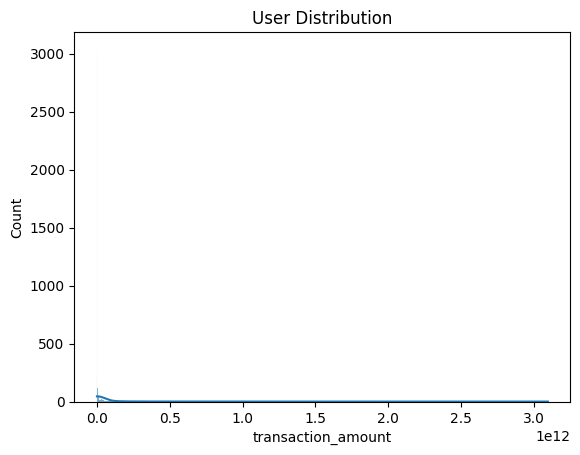

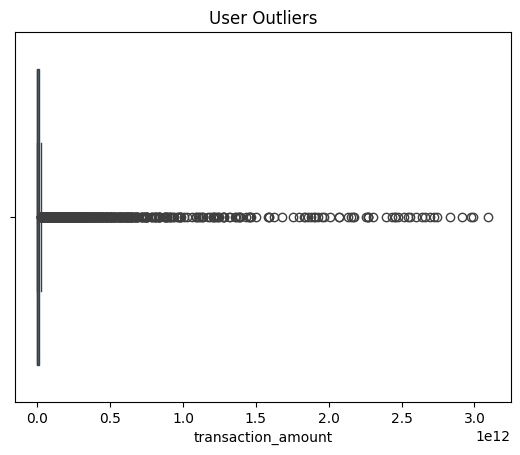

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Summary
print(agg_transaction['transaction_amount'].describe())

# Distribution
sns.histplot(agg_transaction['transaction_amount'], kde=True)
plt.title("User Distribution")
plt.show()

 #Boxplot
sns.boxplot(x=agg_transaction['transaction_amount'])
plt.title("User Outliers")
plt.show()
